In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
import matplotlib.pyplot as plt


home = os.environ.get("HOME")
if not home:
    raise RuntimeError("HOME env not set.")
input_dir = Path(home) / "Projects/Masterarbeit/simdata"
input_file_path = input_dir / "grid_search_data.jsonl"
input_file_path_2 = input_dir / "grid_search_data_2.jsonl"
input_file_path_3 = input_dir / "grid_search_data_3.jsonl"


data1 = pd.read_json(path_or_buf= input_file_path, lines=True)
data2 = pd.read_json(path_or_buf=input_file_path_2, lines=True)
data3 = pd.read_json(path_or_buf=input_file_path_3, lines=True)

print(len(data1))
print(len(data2))
print(len(data3))


630
49
14


In [2]:
data1

,angle,glenohumeral_roll_joint,glenohumeral_yaw_joint,sternoclavicular_pitch_joint,sternoclavicular_yaw_joint,turn
0,115.204076,0.50,0.50,0.10,0.10,0
1,115.226635,0.50,0.50,0.35,0.10,1
2,115.249227,0.50,0.50,0.60,0.10,2
3,115.273805,0.50,0.50,0.85,0.10,3
4,115.296531,0.50,0.50,1.10,0.10,4
...,...,...,...,...,...,...
625,117.467434,1.50,1.50,1.10,1.10,624
626,116.340315,1.25,0.75,0.10,0.60,210
627,117.390835,1.25,1.25,0.60,1.10,472
628,116.137904,0.75,1.50,0.10,0.35,530


In [3]:
data1["turn"].nunique()


625

In [4]:
counts =data1["turn"].value_counts()
data1[data1["turn"].duplicated(keep=False)].sort_values("turn")

,angle,glenohumeral_roll_joint,glenohumeral_yaw_joint,sternoclavicular_pitch_joint,sternoclavicular_yaw_joint,turn
0,115.204076,0.5,0.5,0.10,0.1,0
5,115.212058,0.5,0.5,0.10,0.1,0
1,115.226635,0.5,0.5,0.35,0.1,1
6,115.234604,0.5,0.5,0.35,0.1,1
2,115.249227,0.5,0.5,0.60,0.1,2
7,115.257212,0.5,0.5,0.60,0.1,2
3,115.273805,0.5,0.5,0.85,0.1,3
8,115.279801,0.5,0.5,0.85,0.1,3
4,115.296531,0.5,0.5,1.10,0.1,4
9,115.302316,0.5,0.5,1.10,0.1,4


In [5]:
missing = pd.Index(range(625)).difference(data1["turn"])
missing

Index([], dtype='int64')

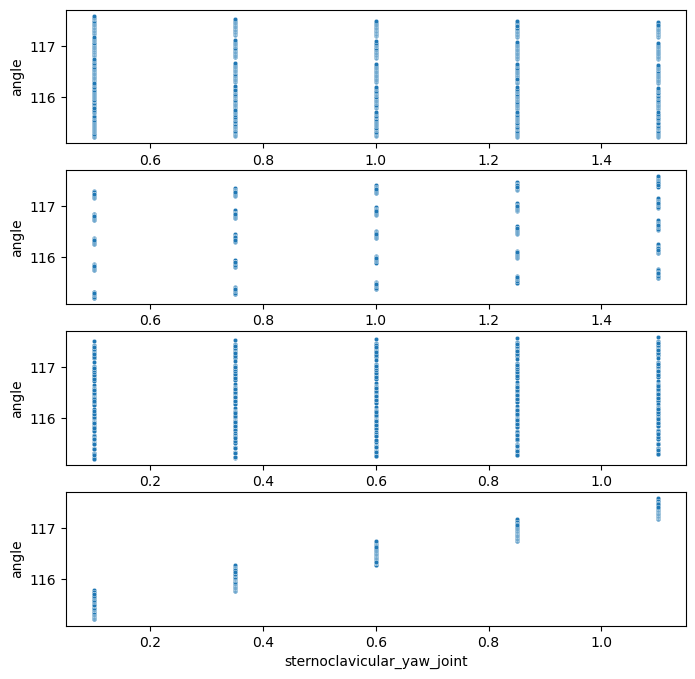

In [6]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8,8))
sns.scatterplot(data1, x="glenohumeral_roll_joint", y="angle", ax=ax1, s=10)
sns.scatterplot(data1, x="glenohumeral_yaw_joint", y="angle", ax=ax2, s=10)
sns.scatterplot(data1, x="sternoclavicular_pitch_joint", y="angle", ax=ax3, s=10)
sns.scatterplot(data1, x="sternoclavicular_yaw_joint", y="angle", ax=ax4, s=10)
plt.show()



In [7]:
# p1= "glenohumeral_roll_joint"
# p2= "glenohumeral_yaw_joint"
# p3= "sternoclavicular_pitch_joint"
# p4= "sternoclavicular_yaw_joint"

# jsonObj = jsonObj.iloc[5:].reset_index(drop=True)


# for (p3, p4), sub in jsonObj.groupby([p3, p4]):
#     pivot = sub.pivot(index=p2, columns=p1, values="angle")
    
#     plt.figure()
#     sns.heatmap(pivot, annot=False, cmap="viridis")
#     plt.title(f"p3={p3}, p4={p4}")
#     plt.xlabel(p1)
#     plt.ylabel(p2)
#     plt.show()

In [8]:
best = data1.loc[data1["angle"].idxmin()]
print(best)

angle                           115.204076
glenohumeral_roll_joint           0.500000
glenohumeral_yaw_joint            0.500000
sternoclavicular_pitch_joint      0.100000
sternoclavicular_yaw_joint        0.100000
turn                              0.000000
Name: 0, dtype: float64


In [9]:
top = data1.nsmallest(20, "angle")
print(top)

          angle  glenohumeral_roll_joint  glenohumeral_yaw_joint  \
0    115.204076                     0.50                     0.5   
105  115.209738                     1.50                     0.5   
80   115.210092                     1.25                     0.5   
5    115.212058                     0.50                     0.5   
55   115.224534                     1.00                     0.5   
30   115.225568                     0.75                     0.5   
1    115.226635                     0.50                     0.5   
106  115.232814                     1.50                     0.5   
81   115.233440                     1.25                     0.5   
6    115.234604                     0.50                     0.5   
56   115.247591                     1.00                     0.5   
31   115.248290                     0.75                     0.5   
2    115.249227                     0.50                     0.5   
107  115.256069                     1.50        

<AxesSubplot: xlabel='glenohumeral_roll_joint', ylabel='sternoclavicular_pitch_joint'>

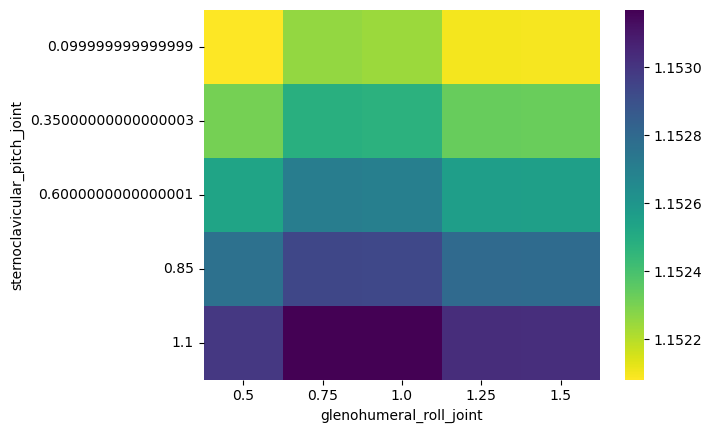

In [10]:
reduced = data1[
    np.isclose(data1["glenohumeral_yaw_joint"], 0.5) &
    np.isclose(data1["sternoclavicular_yaw_joint"], 0.1)
]
reduced = reduced.copy()
reduced["angle"] = reduced["angle"] / 100
pivot = reduced.pivot_table(
    index="sternoclavicular_pitch_joint",
    columns="glenohumeral_roll_joint",
    values="angle",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis_r")

In [11]:
data2

,angle,glenohumeral_roll_joint,sternoclavicular_pitch_joint,turn
0,115.205613,0.25,0.00,0
1,115.209780,0.25,0.05,1
2,115.213874,0.25,0.10,2
3,115.218324,0.25,0.15,3
4,115.222721,0.25,0.20,4
5,115.226815,0.25,0.25,5
6,115.231269,0.25,0.30,6
7,115.198285,0.50,0.00,7
8,115.202866,0.50,0.05,8
9,115.207202,0.50,0.10,9


In [12]:
best_refined = data2.loc[data2["angle"].idxmin()]
best_refined

angle                           115.193177
glenohumeral_roll_joint           1.750000
sternoclavicular_pitch_joint      0.000000
turn                             42.000000
Name: 42, dtype: float64

In [13]:
top_refined = data2.nsmallest(10, "angle")
top_refined

,angle,glenohumeral_roll_joint,sternoclavicular_pitch_joint,turn
42,115.193177,1.75,0.00,42
35,115.193285,1.50,0.00,35
28,115.193992,1.25,0.00,28
21,115.194580,1.00,0.00,21
14,115.195805,0.75,0.00,14
43,115.197634,1.75,0.05,43
36,115.197804,1.50,0.05,36
7,115.198285,0.50,0.00,7
29,115.198348,1.25,0.05,29
22,115.199019,1.00,0.05,22


<AxesSubplot: xlabel='glenohumeral_roll_joint', ylabel='sternoclavicular_pitch_joint'>

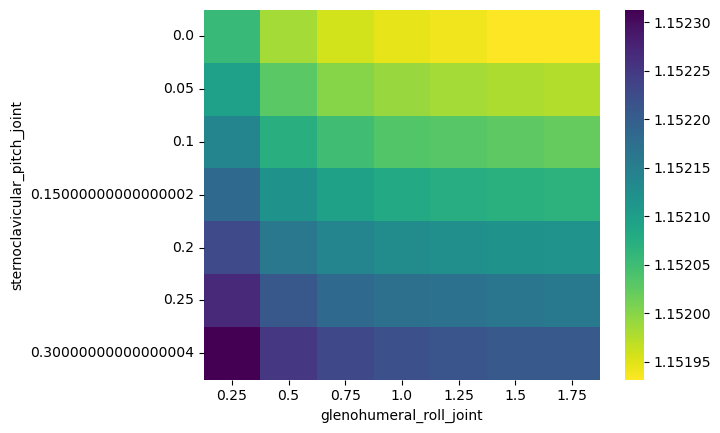

In [14]:
data2["angle"] = data2["angle"] / 100
pivot = data2.pivot_table(
    index="sternoclavicular_pitch_joint",
    columns="glenohumeral_roll_joint",
    values="angle",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis_r")

In [15]:
data3

,angle,glenohumeral_roll_joint,sternoclavicular_pitch_joint,turn
0,115.197688,0.50,0.00,0
1,115.206689,0.50,0.10,2
2,115.195113,0.75,0.00,3
3,115.220607,0.75,0.05,4
4,115.205311,1.00,0.05,7
5,115.204365,1.25,0.05,10
6,115.199701,1.25,0.10,11
7,115.210529,1.50,0.00,12
8,115.178915,1.75,0.00,15
9,115.217599,1.75,0.05,16


In [16]:
best_data3 = data3.loc[data3["angle"].idxmin()]
best_data3

angle                           115.178915
glenohumeral_roll_joint           1.750000
sternoclavicular_pitch_joint      0.000000
turn                             15.000000
Name: 8, dtype: float64

In [17]:
top_data3 = data3.nsmallest(10, "angle")
top_data3

,angle,glenohumeral_roll_joint,sternoclavicular_pitch_joint,turn
8,115.178915,1.75,0.00,15
2,115.195113,0.75,0.00,3
11,115.196457,2.00,0.00,18
0,115.197688,0.50,0.00,0
13,115.199373,11.00,0.05,22
6,115.199701,1.25,0.10,11
5,115.204365,1.25,0.05,10
4,115.205311,1.00,0.05,7
12,115.205720,2.00,0.10,20
1,115.206689,0.50,0.10,2


<AxesSubplot: xlabel='glenohumeral_roll_joint', ylabel='sternoclavicular_pitch_joint'>

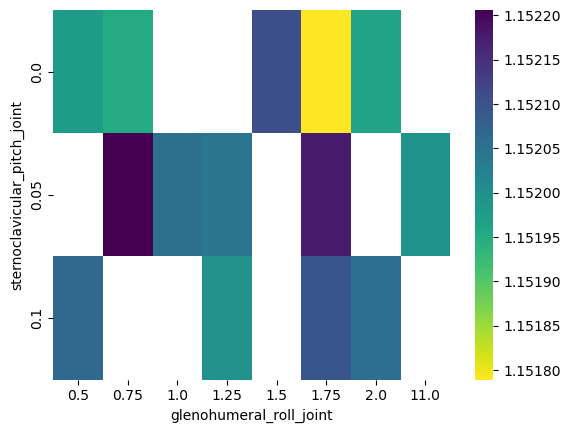

In [18]:
data3["angle"] = data3["angle"] / 100
pivot = data3.pivot_table(
    index="sternoclavicular_pitch_joint",
    columns="glenohumeral_roll_joint",
    values="angle",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis_r")